# Walmart Sales Forecasting
### BSc Computer Science Final Year Project
**Dataset:** Walmart Store Sales Forecasting (Kaggle)

---

## Project Overview
This project aims to forecast Walmart store sales across 45 stores and 81+ departments using machine learning models.
We combine store metadata, temporal information, and economic indicators to predict weekly sales with three different models:
**Linear Regression, Random Forest, and XGBoost**.

The analysis is structured in three parts:
1. **Data Loading, Merging & Understanding** - Load and prepare all datasets
2. **EDA & Feature Engineering** - Explore patterns and engineer temporal features
3. **Model Training, Evaluation & Prediction** - Train and compare models

---

# PART 1: DATA LOADING, MERGING & UNDERSTANDING

## 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1.2 Load and Merge All Three Datasets
### We merge all 3 source files into one unified dataset

In [2]:
# Locate data files — works both locally and in this environment
data_dir = os.path.dirname(os.path.abspath('walmart_sales_forecasting.ipynb'))
if not os.path.exists(os.path.join(data_dir, 'train.csv')):
    data_dir = '/sessions/festive-great-meitner/mnt/utsav'

# Load the three source files
print("Loading source files...")
train    = pd.read_csv(f'{data_dir}/train.csv')
features = pd.read_csv(f'{data_dir}/features.csv')
stores   = pd.read_csv(f'{data_dir}/stores.csv')

print(f"✓ train.csv: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"✓ features.csv: {features.shape[0]:,} rows × {features.shape[1]} columns")
print(f"✓ stores.csv: {stores.shape[0]} rows × {stores.shape[1]} columns")

Loading source files...


✓ train.csv: 421,570 rows × 5 columns
✓ features.csv: 8,190 rows × 12 columns
✓ stores.csv: 45 rows × 3 columns


### Merge Step 1: Convert Date Columns

In [3]:
# Parse date columns
train['Date']    = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

print("Dates converted to datetime format")

Dates converted to datetime format


### Merge Step 2: Merge Stores Data (by Store ID)

In [4]:
# Merge stores info into train data
merged_data = train.merge(stores, on='Store', how='left')

print(f"After merging stores: {merged_data.shape[0]:,} rows × {merged_data.shape[1]} columns")

After merging stores: 421,570 rows × 7 columns


### Merge Step 3: Merge Features Data (by Store & Date)

In [5]:
# Merge features (economic indicators, temperature, etc.) into the combined data
merged_data = merged_data.merge(features, on=['Store', 'Date'], how='left')

print(f"After merging features: {merged_data.shape[0]:,} rows × {merged_data.shape[1]} columns")
print(f"\nColumn list: {list(merged_data.columns)}")

After merging features: 421,570 rows × 17 columns

Column list: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y']


### Merge Step 4: Handle Duplicate IsHoliday Columns & Missing Values

In [6]:
# Resolve duplicate IsHoliday columns created by the merge
if 'IsHoliday_x' in merged_data.columns:
    merged_data['IsHoliday'] = merged_data['IsHoliday_x'].fillna(merged_data['IsHoliday_y'])
    merged_data = merged_data.drop(['IsHoliday_x', 'IsHoliday_y'], axis=1)
    print("✓ Resolved duplicate IsHoliday columns")

# Fill missing values with column mean
merged_data['CPI'].fillna(merged_data['CPI'].mean(), inplace=True)
merged_data['Unemployment'].fillna(merged_data['Unemployment'].mean(), inplace=True)
merged_data['Temperature'].fillna(merged_data['Temperature'].mean(), inplace=True)

print("✓ Filled missing values (CPI, Unemployment, Temperature) with column means")

# Check for remaining missing values
missing = merged_data.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values remaining")
else:
    print(f"Remaining missing values:\n{missing[missing > 0]}")

✓ Resolved duplicate IsHoliday columns
✓ Filled missing values (CPI, Unemployment, Temperature) with column means
Remaining missing values:
MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64


### Merge Step 5: Save Unified Dataset

In [7]:
# Save the merged dataset as a single CSV for future use
merged_path = f'{data_dir}/walmart_merged.csv'
merged_data.to_csv(merged_path, index=False)
print(f"✓ Unified dataset saved to: {merged_path}")
print(f"  Shape: {merged_data.shape[0]:,} rows × {merged_data.shape[1]} columns")

✓ Unified dataset saved to: /sessions/festive-great-meitner/mnt/utsav/walmart_merged.csv
  Shape: 421,570 rows × 16 columns


## 1.3 Dataset Summary & Understanding

In [8]:
# Table 1: Dataset Summary
summary = pd.DataFrame({
    'Metric': ['Total Records', 'Total Features', 'Date Range Start',
               'Date Range End', 'Unique Stores', 'Unique Departments',
               'Missing Values (post-fill)'],
    'Value': [
        f'{merged_data.shape[0]:,}',
        str(merged_data.shape[1]),
        str(merged_data['Date'].min().date()),
        str(merged_data['Date'].max().date()),
        str(merged_data['Store'].nunique()),
        str(merged_data['Dept'].nunique()),
        '0'
    ]
})
print("Table 1: Unified Dataset Summary\n")
print(summary.to_string(index=False))

Table 1: Unified Dataset Summary

                    Metric      Value
             Total Records    421,570
            Total Features         16
          Date Range Start 2010-02-05
            Date Range End 2012-10-26
             Unique Stores         45
        Unique Departments         81
Missing Values (post-fill)          0


In [9]:
# Table 2: Feature Descriptions
feature_desc = pd.DataFrame({
    'Feature':     ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday',
                    'Temperature', 'Fuel_Price', 'MarkDown1-5', 'CPI', 'Unemployment', 'Type', 'Size'],
    'Type':        ['int', 'int', 'datetime', 'float', 'bool',
                    'float', 'float', 'float', 'float', 'float', 'str', 'int'],
    'Description': ['Store ID (1–45)', 'Department ID (1–99)', 'Week start date',
                    'Total weekly sales (USD)', 'Holiday week flag',
                    'Regional temperature (°F)', 'Regional fuel price',
                    'Anonymised markdown data', 'Consumer Price Index',
                    'Unemployment rate', 'Store type (A / B / C)', 'Store size (sq ft)']
})
print("\nTable 2: Feature Descriptions\n")
print(feature_desc.to_string(index=False))


Table 2: Feature Descriptions

     Feature     Type               Description
       Store      int           Store ID (1–45)
        Dept      int      Department ID (1–99)
        Date datetime           Week start date
Weekly_Sales    float  Total weekly sales (USD)
   IsHoliday     bool         Holiday week flag
 Temperature    float Regional temperature (°F)
  Fuel_Price    float       Regional fuel price
 MarkDown1-5    float  Anonymised markdown data
         CPI    float      Consumer Price Index
Unemployment    float         Unemployment rate
        Type      str    Store type (A / B / C)
        Size      int        Store size (sq ft)


---

# PART 2: EDA & FEATURE ENGINEERING

## 2.1 Exploratory Data Analysis: Temperature vs Sales

In [10]:
# Load the unified dataset (alternatively continue from above)
data_dir = os.path.dirname(os.path.abspath('walmart_sales_forecasting.ipynb'))
if not os.path.exists(os.path.join(data_dir, 'walmart_merged.csv')):
    data_dir = '/sessions/festive-great-meitner/mnt/utsav'

merged_data = pd.read_csv(f'{data_dir}/walmart_merged.csv')
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

print(f"Loaded unified dataset: {merged_data.shape[0]:,} rows × {merged_data.shape[1]} columns")

Loaded unified dataset: 421,570 rows × 16 columns


In [11]:
# Compute Pearson correlation between temperature and weekly sales
temp_sales_corr = merged_data['Temperature'].corr(merged_data['Weekly_Sales'])
print(f"Pearson r (Temperature vs Weekly_Sales): {temp_sales_corr:.4f}")

# Bin temperature into quartiles for grouped analysis
merged_data['Temp_Quartile'] = pd.qcut(merged_data['Temperature'], q=4, labels=['Cold', 'Cool', 'Warm', 'Hot'])

# Summary stats per quartile
temp_analysis = merged_data.groupby('Temp_Quartile').agg(
    Mean_Sales   = ('Weekly_Sales', 'mean'),
    Median_Sales = ('Weekly_Sales', 'median'),
    Std_Sales    = ('Weekly_Sales', 'std'),
    Min_Temp     = ('Temperature',  'min'),
    Max_Temp     = ('Temperature',  'max'),
    Count        = ('Weekly_Sales', 'count')
).round(2)

print("\nTable 3: Sales by Temperature Quartile\n")
print(temp_analysis.to_string())

Pearson r (Temperature vs Weekly_Sales): -0.0023

Table 3: Sales by Temperature Quartile

               Mean_Sales  Median_Sales  Std_Sales  Min_Temp  Max_Temp   Count
Temp_Quartile                                                                 
Cold             16014.98       7569.11   23473.35     -2.06     46.68  105400
Cool             16022.44       7718.13   22962.64     46.70     62.09  105437
Warm             16032.92       7830.71   22001.08     62.10     74.28  105373
Hot              15854.65       7359.47   22379.41     74.29    100.14  105360


✓ Saved: /sessions/festive-great-meitner/mnt/utsav/figure_1_temperature_analysis.png


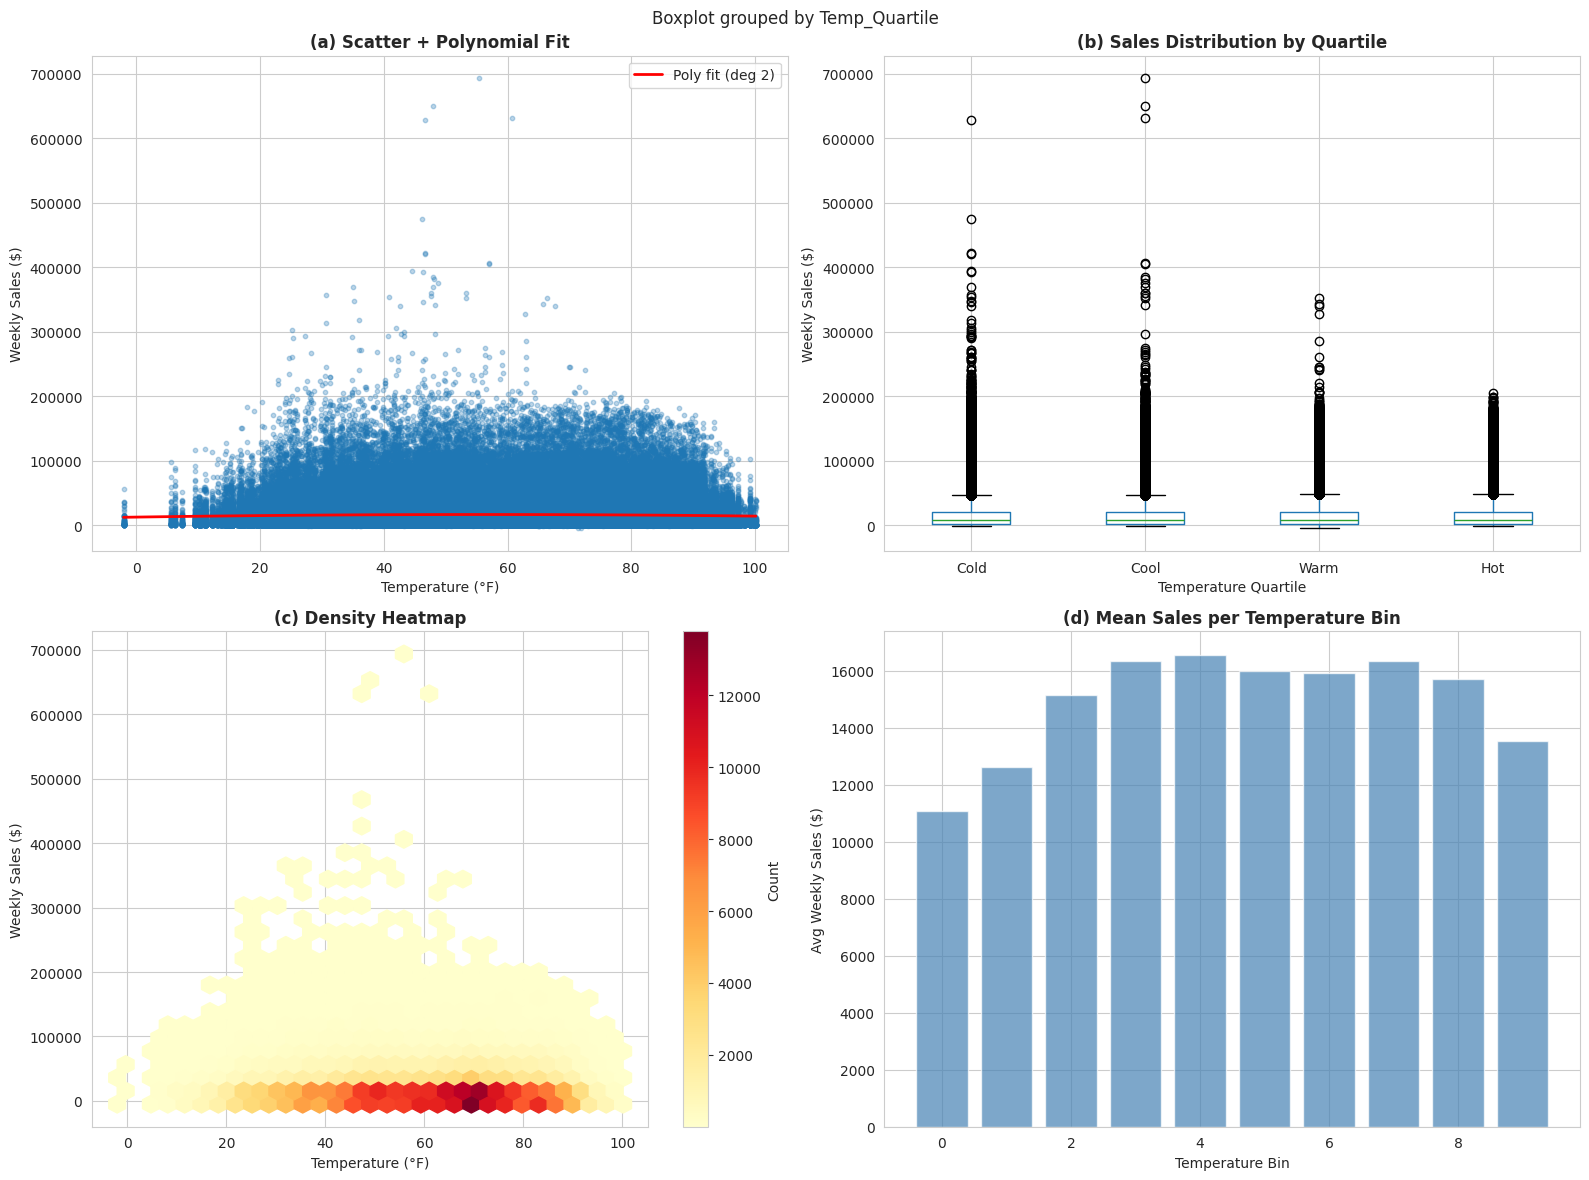

In [12]:
# Figure 1: Temperature vs Weekly Sales Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Figure 1: Temperature vs Weekly Sales Analysis', fontsize=14, fontweight='bold')

# Scatter with polynomial fit
axes[0, 0].scatter(merged_data['Temperature'], merged_data['Weekly_Sales'], alpha=0.3, s=10)
z = np.polyfit(merged_data['Temperature'], merged_data['Weekly_Sales'], 2)
p = np.poly1d(z)
x_line = np.linspace(merged_data['Temperature'].min(), merged_data['Temperature'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), 'r-', lw=2, label='Poly fit (deg 2)')
axes[0, 0].set_xlabel('Temperature (°F)')
axes[0, 0].set_ylabel('Weekly Sales ($)')
axes[0, 0].set_title('(a) Scatter + Polynomial Fit', fontweight='bold')
axes[0, 0].legend()

# Box plot by quartile
merged_data.boxplot(column='Weekly_Sales', by='Temp_Quartile', ax=axes[0, 1])
axes[0, 1].set_xlabel('Temperature Quartile')
axes[0, 1].set_ylabel('Weekly Sales ($)')
axes[0, 1].set_title('(b) Sales Distribution by Quartile', fontweight='bold')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# Density heatmap
hb = axes[1, 0].hexbin(merged_data['Temperature'], merged_data['Weekly_Sales'], gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1, 0].set_xlabel('Temperature (°F)')
axes[1, 0].set_ylabel('Weekly Sales ($)')
axes[1, 0].set_title('(c) Density Heatmap', fontweight='bold')
plt.colorbar(hb, ax=axes[1, 0], label='Count')

# Average sales per temperature bin
temp_bins = pd.cut(merged_data['Temperature'], bins=10)
sales_by_bin = merged_data.groupby(temp_bins)['Weekly_Sales'].mean()
axes[1, 1].bar(range(len(sales_by_bin)), sales_by_bin.values, color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Temperature Bin')
axes[1, 1].set_ylabel('Avg Weekly Sales ($)')
axes[1, 1].set_title('(d) Mean Sales per Temperature Bin', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{data_dir}/figure_1_temperature_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {data_dir}/figure_1_temperature_analysis.png")
plt.show()

In [13]:
# Table 4: Key EDA Findings
findings = pd.DataFrame({
    'Finding': [
        'Correlation direction',
        'Correlation strength',
        'Avg sales — Hot quartile',
        'Avg sales — Cold quartile',
        'Difference (Hot − Cold)'
    ],
    'Result': [
        'Positive' if temp_sales_corr > 0 else 'Negative',
        'Weak' if abs(temp_sales_corr) < 0.3 else 'Moderate',
        f"${merged_data[merged_data['Temp_Quartile'] == 'Hot']['Weekly_Sales'].mean():,.2f}",
        f"${merged_data[merged_data['Temp_Quartile'] == 'Cold']['Weekly_Sales'].mean():,.2f}",
        f"${merged_data[merged_data['Temp_Quartile'] == 'Hot']['Weekly_Sales'].mean() - merged_data[merged_data['Temp_Quartile'] == 'Cold']['Weekly_Sales'].mean():,.2f}"
    ]
})
print("\nTable 4: Temperature–Sales Key Findings\n")
print(findings.to_string(index=False))


Table 4: Temperature–Sales Key Findings

                  Finding     Result
    Correlation direction   Negative
     Correlation strength       Weak
 Avg sales — Hot quartile $15,854.65
Avg sales — Cold quartile $16,014.98
  Difference (Hot − Cold)   $-160.33


## 2.2 Department-Level Analysis

In [14]:
# Create a Store–Department combination label for granular analysis
merged_data['StoreDept'] = merged_data['Store'].astype(str) + '_' + merged_data['Dept'].astype(str)

# Aggregate sales stats per department
dept_summary = merged_data.groupby('Dept').agg(
    Avg_Sales = ('Weekly_Sales', 'mean'),
    Std_Sales = ('Weekly_Sales', 'std'),
    Min_Sales = ('Weekly_Sales', 'min'),
    Max_Sales = ('Weekly_Sales', 'max'),
    Records   = ('Store', 'count')
).round(2).sort_values('Avg_Sales', ascending=False)

print("Table 5: Top 10 Departments by Avg Weekly Sales\n")
print(dept_summary.head(10).to_string())

Table 5: Top 10 Departments by Avg Weekly Sales

      Avg_Sales  Std_Sales  Min_Sales  Max_Sales  Records
Dept                                                     
92     75204.87   49413.73    4411.43  293966.05     6435
95     69824.42   38200.54   11158.06  213042.66     6435
38     61090.62   23966.91    6199.58  172794.20     6435
72     50566.52   44710.98    -379.00  693099.36     6046
65     45441.71    7086.89   26643.97   61588.84      143
90     45232.08   32462.02     461.70  166263.81     6435
40     44900.70   21903.88    4104.89  119463.15     6435
2      43607.02   25176.76    5453.18  151090.50     6435
91     33687.91   26247.46      13.68  162497.78     6435
94     33405.88   25405.56    -173.84  103929.39     5685


In [15]:
# Overall store-department stats
dept_stats = pd.DataFrame({
    'Metric': ['Total Departments', 'Total Store–Dept Combinations',
               'Mean Records per Combination', 'Min Records', 'Max Records'],
    'Value':  [
        merged_data['Dept'].nunique(),
        merged_data['StoreDept'].nunique(),
        f"{merged_data.groupby('StoreDept').size().mean():.0f}",
        merged_data.groupby('StoreDept').size().min(),
        merged_data.groupby('StoreDept').size().max()
    ]
})
print("\nTable 6: Store–Department Statistics\n")
print(dept_stats.to_string(index=False))


Table 6: Store–Department Statistics

                       Metric Value
            Total Departments    81
Total Store–Dept Combinations  3331
 Mean Records per Combination   127
                  Min Records     1
                  Max Records   143


✓ Saved: /sessions/festive-great-meitner/mnt/utsav/figure_2_department_analysis.png


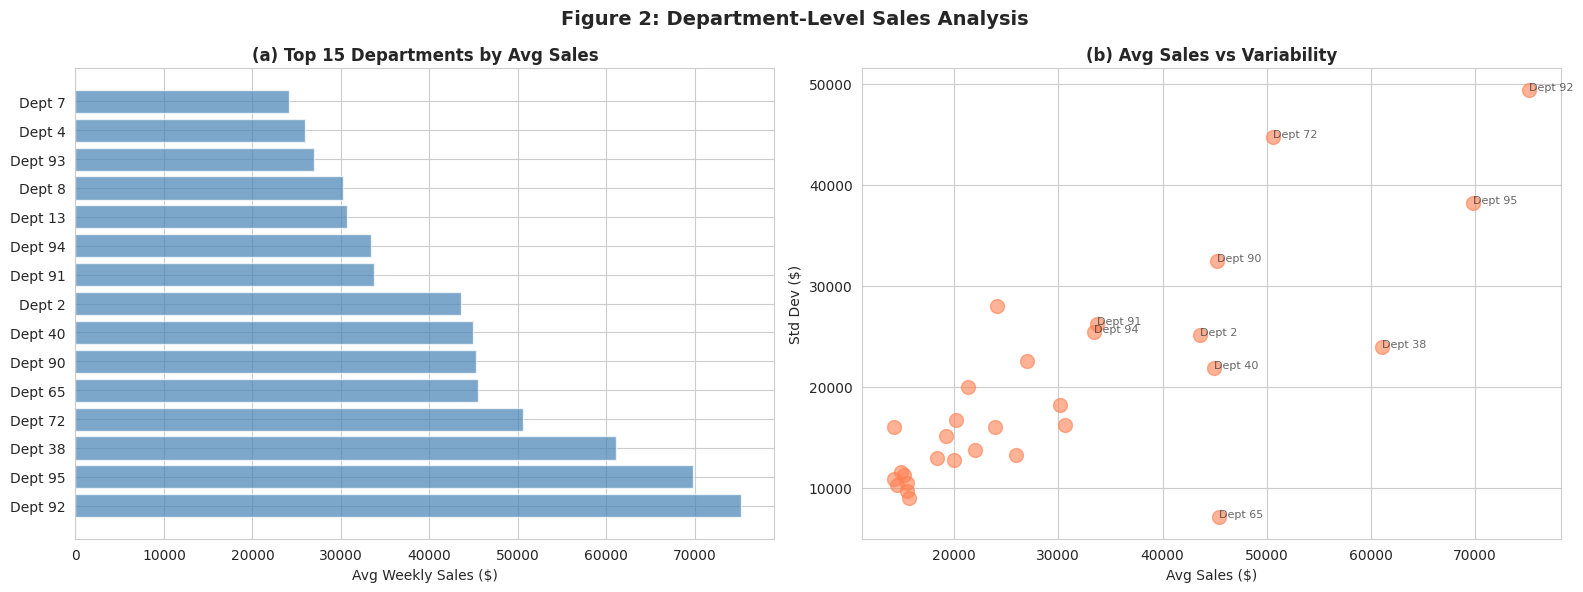

In [16]:
# Figure 2: Department-Level Sales Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 2: Department-Level Sales Analysis', fontsize=14, fontweight='bold')

# Top 15 departments by average sales
top15 = dept_summary.head(15)
axes[0].barh(range(len(top15)), top15['Avg_Sales'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels([f'Dept {i}' for i in top15.index])
axes[0].set_xlabel('Avg Weekly Sales ($)')
axes[0].set_title('(a) Top 15 Departments by Avg Sales', fontweight='bold')

# Mean vs variability scatter for top 30
top30 = dept_summary.head(30)
axes[1].scatter(top30['Avg_Sales'], top30['Std_Sales'], s=100, alpha=0.6, color='coral')
for idx in top30.head(10).index:
    r = dept_summary.loc[idx]
    axes[1].annotate(f'Dept {idx}', (r['Avg_Sales'], r['Std_Sales']), fontsize=8, alpha=0.7)
axes[1].set_xlabel('Avg Sales ($)')
axes[1].set_ylabel('Std Dev ($)')
axes[1].set_title('(b) Avg Sales vs Variability', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{data_dir}/figure_2_department_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {data_dir}/figure_2_department_analysis.png")
plt.show()

## 2.3 Feature Engineering

In [17]:
# Extract temporal features from the date column
merged_data['Year']      = merged_data['Date'].dt.year
merged_data['Month']     = merged_data['Date'].dt.month
merged_data['Week']      = merged_data['Date'].dt.isocalendar().week.astype(int)
merged_data['DayOfWeek'] = merged_data['Date'].dt.dayofweek
merged_data['Quarter']   = merged_data['Date'].dt.quarter

print("✓ Extracted temporal features: Year, Month, Week, DayOfWeek, Quarter")

# Encode the store Type column (A/B/C → 0/1/2)
le = LabelEncoder()
merged_data['Type_Encoded'] = le.fit_transform(merged_data['Type'].fillna('A'))

print("✓ Encoded Type column (A/B/C → 0/1/2)")

# Convert boolean IsHoliday to int
merged_data['IsHoliday'] = merged_data['IsHoliday'].astype(int)

print("✓ Converted IsHoliday to integer")

✓ Extracted temporal features: Year, Month, Week, DayOfWeek, Quarter
✓ Encoded Type column (A/B/C → 0/1/2)
✓ Converted IsHoliday to integer


In [18]:
# Final feature set — dropped MarkDown1-5 (65% missing) and Fuel_Price (low correlation)
feature_cols = [
    'Store', 'Dept', 'Size', 'Temperature', 'CPI', 'Unemployment',
    'IsHoliday', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Type_Encoded'
]

# Table 7: Selected Features
feat_table = pd.DataFrame({
    'No.':     range(1, len(feature_cols) + 1),
    'Feature': feature_cols,
    'Category': ['Store', 'Store', 'Store', 'Economic', 'Economic', 'Economic',
                 'Seasonal', 'Temporal', 'Temporal', 'Temporal', 'Temporal', 'Temporal', 'Store'],
    'Source':   ['Merged', 'Merged', 'Merged', 'Merged', 'Merged',
                 'Merged', 'Merged', 'Derived', 'Derived', 'Derived', 'Derived', 'Derived', 'Encoded']
})
print("Table 7: Final Feature Set\n")
print(feat_table.to_string(index=False))

Table 7: Final Feature Set

 No.      Feature Category  Source
   1        Store    Store  Merged
   2         Dept    Store  Merged
   3         Size    Store  Merged
   4  Temperature Economic  Merged
   5          CPI Economic  Merged
   6 Unemployment Economic  Merged
   7    IsHoliday Seasonal  Merged
   8         Year Temporal Derived
   9        Month Temporal Derived
  10         Week Temporal Derived
  11    DayOfWeek Temporal Derived
  12      Quarter Temporal Derived
  13 Type_Encoded    Store Encoded


In [19]:
# Table 8: Removed Features
removed = pd.DataFrame({
    'Feature': ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Fuel_Price'],
    'Reason':  ['~65% missing values'] * 5 + ['Low correlation with Weekly_Sales']
})
print("\nTable 8: Removed Features\n")
print(removed.to_string(index=False))


Table 8: Removed Features

   Feature                            Reason
 MarkDown1               ~65% missing values
 MarkDown2               ~65% missing values
 MarkDown3               ~65% missing values
 MarkDown4               ~65% missing values
 MarkDown5               ~65% missing values
Fuel_Price Low correlation with Weekly_Sales


---

# PART 3: MODEL TRAINING, EVALUATION & PREDICTION

## 3.1 Train-Test Split (80/20 Time-Based)

In [20]:
# Time-based 80/20 split — keeps temporal order, avoids data leakage
# 80% for training, 20% for testing/prediction
split_date = merged_data['Date'].quantile(0.8)
train_data = merged_data[merged_data['Date'] <= split_date].copy()
val_data   = merged_data[merged_data['Date'] >  split_date].copy()

X_train = train_data[feature_cols]
y_train = train_data['Weekly_Sales']
X_val   = val_data[feature_cols]
y_val   = val_data['Weekly_Sales']

# Scale features
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Split summary
split_summary = pd.DataFrame({
    'Set':        ['Training (80%)', 'Validation (20%)'],
    'Start Date': [str(train_data['Date'].min().date()), str(val_data['Date'].min().date())],
    'End Date':   [str(train_data['Date'].max().date()), str(val_data['Date'].max().date())],
    'Samples':    [f'{len(train_data):,}', f'{len(val_data):,}'],
    'Share':      [f'{len(train_data)/len(merged_data)*100:.1f}%', f'{len(val_data)/len(merged_data)*100:.1f}%']
})
print("Table 9: Train–Validation Split (80/20 Time-Based)\n")
print(split_summary.to_string(index=False))

Table 9: Train–Validation Split (80/20 Time-Based)

             Set Start Date   End Date Samples Share
  Training (80%) 2010-02-05 2012-04-13 338,738 80.4%
Validation (20%) 2012-04-20 2012-10-26  82,832 19.6%


## 3.2 Train Three Models: Linear Regression, Random Forest, XGBoost

In [21]:
# Model 1: Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_val_scaled)
print("✓ Linear Regression trained")

# Model 2: Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_val)
print("✓ Random Forest trained")

# Model 3: XGBoost
print("\nTraining XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                               random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_scaled, y_train, verbose=False)
xgb_pred = xgb_model.predict(X_val_scaled)
print("✓ XGBoost trained")

Training Linear Regression...


✓ Linear Regression trained

Training Random Forest...


✓ Random Forest trained

Training XGBoost...


✓ XGBoost trained


In [22]:
# Table 10: Model Hyperparameters
params = pd.DataFrame({
    'Parameter':       ['Algorithm', 'n_estimators', 'max_depth', 'learning_rate', 'random_state'],
    'Linear Regression': ['—', '—', '—', '—', '—'],
    'Random Forest':   ['Decision Trees', '100', '15', '—', '42'],
    'XGBoost':         ['Gradient Boosting', '100', '6', '0.1', '42']
})
print("Table 10: Model Hyperparameters\n")
print(params.to_string(index=False))

Table 10: Model Hyperparameters

    Parameter Linear Regression  Random Forest           XGBoost
    Algorithm                 — Decision Trees Gradient Boosting
 n_estimators                 —            100               100
    max_depth                 —             15                 6
learning_rate                 —              —               0.1
 random_state                 —             42                42


## 3.3 Model Evaluation & Comparison

In [23]:
# Calculate MAE, RMSE and R² for all three models
lr_mae  = mean_absolute_error(y_val, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))
lr_r2   = r2_score(y_val, lr_pred)

rf_mae  = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_r2   = r2_score(y_val, rf_pred)

xgb_mae  = mean_absolute_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2   = r2_score(y_val, xgb_pred)

# Table 11: Performance Comparison
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE ($)':  [f'{lr_mae:,.2f}',  f'{rf_mae:,.2f}',  f'{xgb_mae:,.2f}'],
    'RMSE ($)': [f'{lr_rmse:,.2f}', f'{rf_rmse:,.2f}', f'{xgb_rmse:,.2f}'],
    'R²':       [f'{lr_r2:.4f}',    f'{rf_r2:.4f}',    f'{xgb_r2:.4f}']
})
print("Table 11: Model Performance Comparison (All 3 Models)\n")
print(results.to_string(index=False))

# Identify best model by RMSE
rmse_values = {'Linear Regression': lr_rmse, 'Random Forest': rf_rmse, 'XGBoost': xgb_rmse}
best_name = min(rmse_values, key=rmse_values.get)
best_rmse = rmse_values[best_name]

print(f"\n✓ Best model: {best_name} (RMSE = ${best_rmse:,.2f})")

Table 11: Model Performance Comparison (All 3 Models)

            Model   MAE ($)  RMSE ($)     R²
Linear Regression 14,658.81 20,947.40 0.0907
    Random Forest  2,167.09  4,238.28 0.9628
          XGBoost  3,863.52  6,397.52 0.9152

✓ Best model: Random Forest (RMSE = $4,238.28)


✓ Saved: /sessions/festive-great-meitner/mnt/utsav/figure_3_model_comparison.png


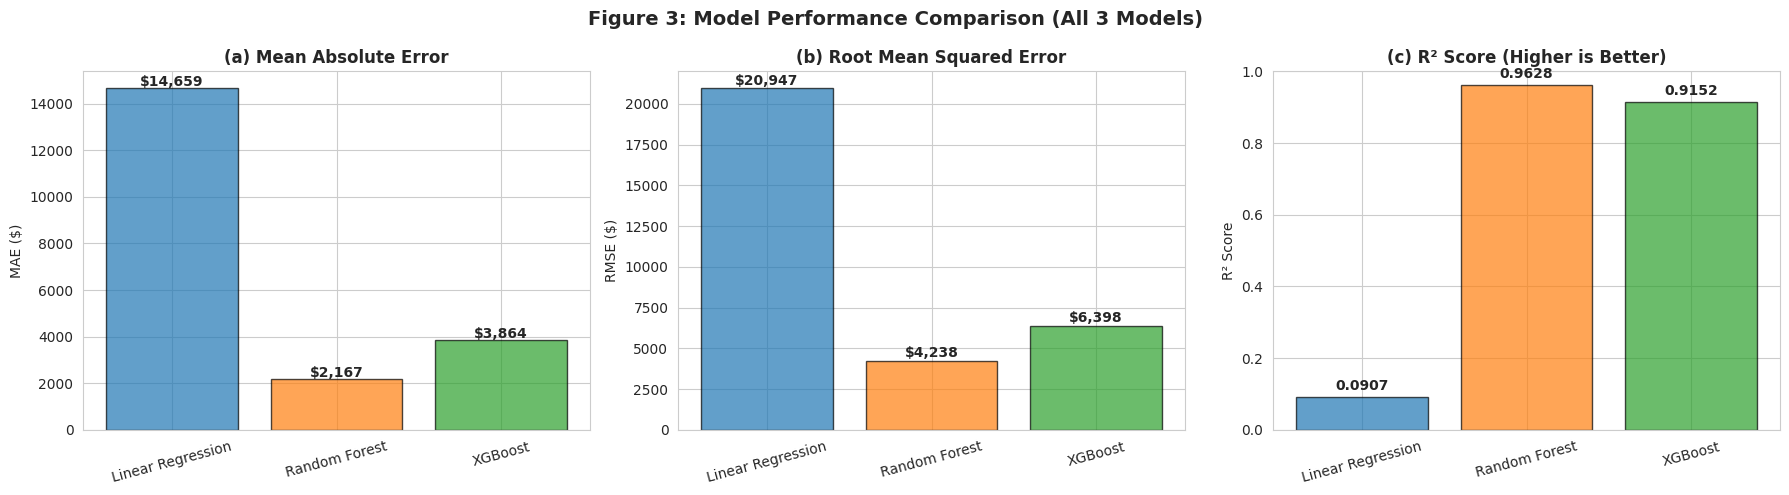

In [24]:
# Figure 3: Model Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 3: Model Performance Comparison (All 3 Models)', fontsize=14, fontweight='bold')

models = ['Linear Regression', 'Random Forest', 'XGBoost']
mae_vals = [lr_mae, rf_mae, xgb_mae]
rmse_vals = [lr_rmse, rf_rmse, xgb_rmse]
r2_vals = [lr_r2, rf_r2, xgb_r2]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# MAE Comparison
axes[0].bar(models, mae_vals, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('MAE ($)')
axes[0].set_title('(a) Mean Absolute Error', fontweight='bold')
for i, v in enumerate(mae_vals):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# RMSE Comparison
axes[1].bar(models, rmse_vals, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('(b) Root Mean Squared Error', fontweight='bold')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 200, f'${v:,.0f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# R² Comparison
axes[2].bar(models, r2_vals, color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('R² Score')
axes[2].set_title('(c) R² Score (Higher is Better)', fontweight='bold')
axes[2].set_ylim([0, 1])
for i, v in enumerate(r2_vals):
    axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{data_dir}/figure_3_model_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {data_dir}/figure_3_model_comparison.png")
plt.show()

## 3.4 Best Model Analysis & Residuals

✓ Saved: /sessions/festive-great-meitner/mnt/utsav/figure_4_best_model_evaluation.png


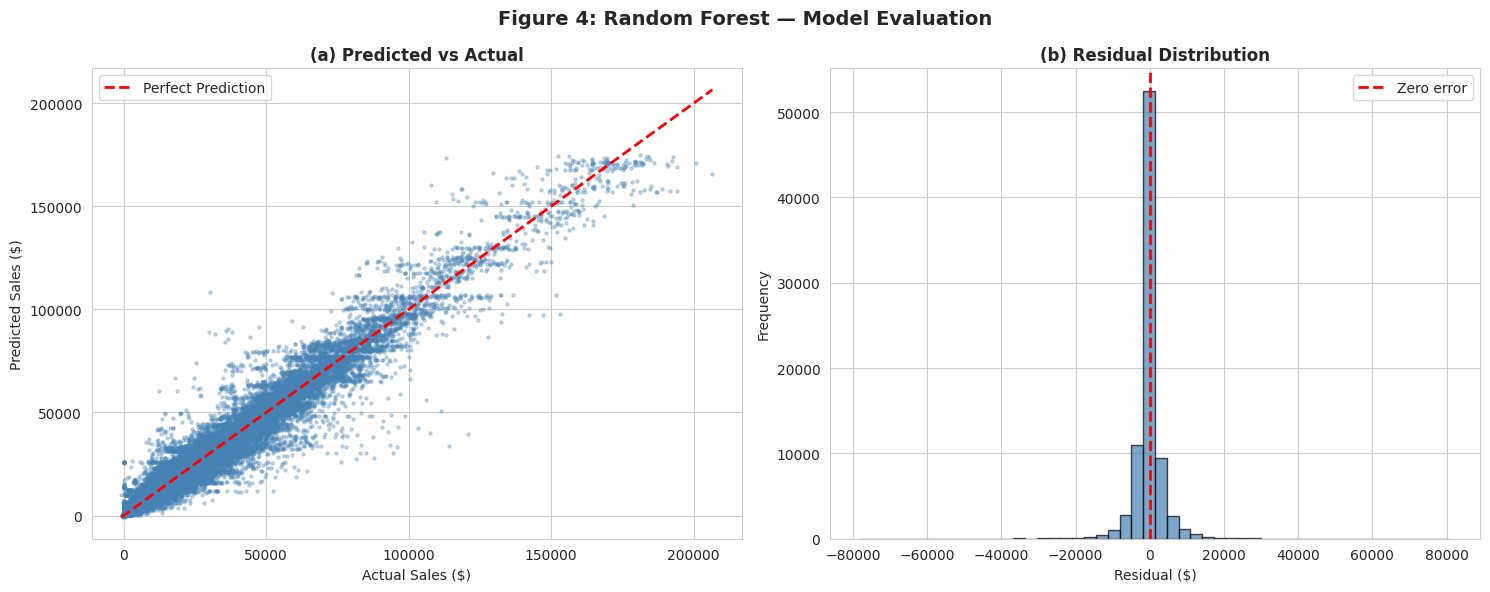

In [25]:
# Select best model predictions
if best_name == 'Linear Regression':
    best_pred = lr_pred
    best_r2 = lr_r2
elif best_name == 'Random Forest':
    best_pred = rf_pred
    best_r2 = rf_r2
else:  # XGBoost
    best_pred = xgb_pred
    best_r2 = xgb_r2

# Figure 4: Best Model Evaluation Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Figure 4: {best_name} — Model Evaluation', fontsize=14, fontweight='bold')

# Predicted vs actual
axes[0].scatter(y_val, best_pred, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')
axes[0].set_title('(a) Predicted vs Actual', fontweight='bold')
axes[0].legend()

# Residual distribution
residuals = y_val.values - best_pred
axes[1].hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='Zero error')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('(b) Residual Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{data_dir}/figure_4_best_model_evaluation.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {data_dir}/figure_4_best_model_evaluation.png")
plt.show()

In [26]:
# Table 12: Residual Statistics
res_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Std Dev', 'Min', 'Max'],
    'Value ($)': [f'{residuals.mean():,.2f}', f'{np.median(residuals):,.2f}',
                  f'{residuals.std():,.2f}',   f'{residuals.min():,.2f}',
                  f'{residuals.max():,.2f}']
})
print("Table 12: Residual Statistics\n")
print(res_stats.to_string(index=False))

Table 12: Residual Statistics

Statistic  Value ($)
     Mean    -188.55
   Median     -93.49
  Std Dev   4,234.08
      Min -78,204.43
      Max  81,047.07


## 3.5 Feature Importance Analysis

In [27]:
# Extract feature importance scores from tree-based models (RF and XGBoost)
rf_imp = pd.DataFrame({
    'Feature':       feature_cols,
    'RF Importance': rf_model.feature_importances_
}).sort_values('RF Importance', ascending=False).reset_index(drop=True)

xgb_imp = pd.DataFrame({
    'Feature':            feature_cols,
    'XGBoost Importance': xgb_model.feature_importances_
}).sort_values('XGBoost Importance', ascending=False).reset_index(drop=True)

# For Linear Regression, use absolute coefficient values
lr_imp = pd.DataFrame({
    'Feature':         feature_cols,
    'LR Abs Coef':     np.abs(lr_model.coef_)
}).sort_values('LR Abs Coef', ascending=False).reset_index(drop=True)

print("Table 13: Top 10 Features by Random Forest Importance\n")
print(rf_imp.head(10).to_string(index=False))

Table 13: Top 10 Features by Random Forest Importance

     Feature  RF Importance
        Dept       0.632055
        Size       0.198620
       Store       0.052712
        Week       0.045373
         CPI       0.026099
Type_Encoded       0.013997
Unemployment       0.011530
 Temperature       0.008796
       Month       0.008079
   IsHoliday       0.001588


✓ Saved: /sessions/festive-great-meitner/mnt/utsav/figure_5_feature_importance.png


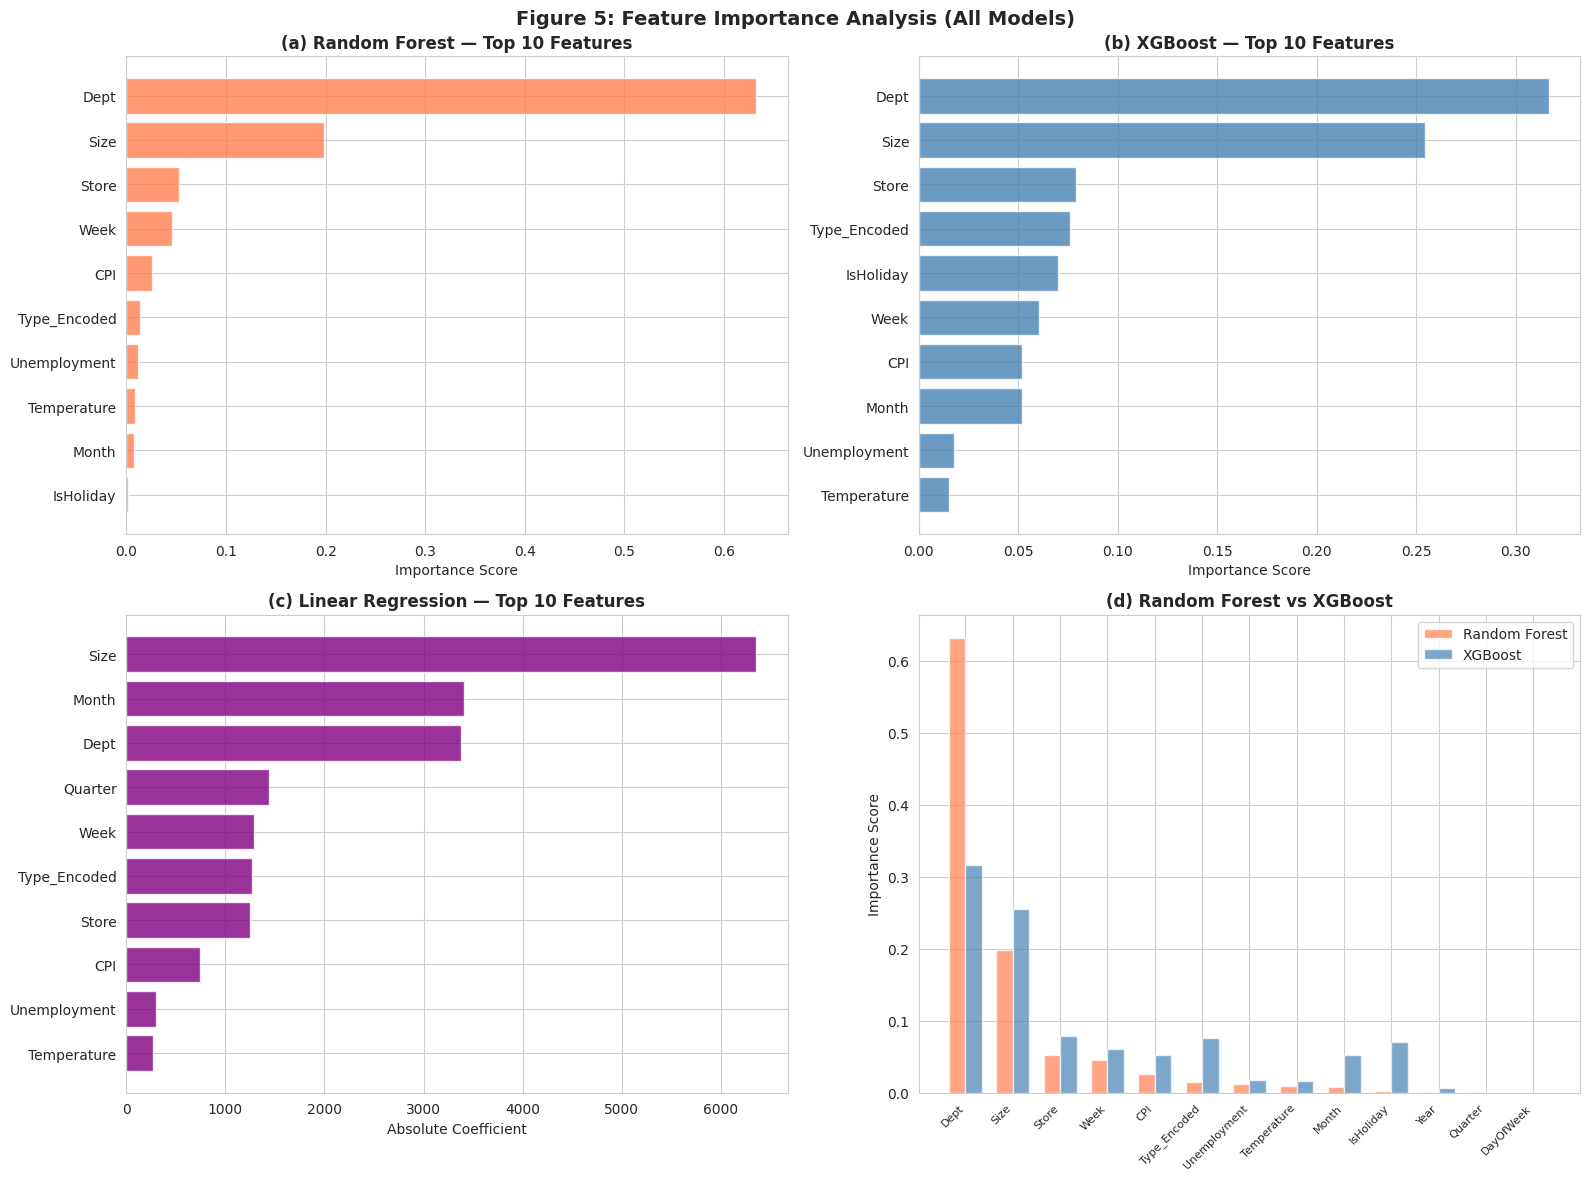

In [28]:
# Figure 5: Feature Importance Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Figure 5: Feature Importance Analysis (All Models)', fontsize=14, fontweight='bold')

# Random Forest top 10
top10_rf = rf_imp.head(10).sort_values('RF Importance')
axes[0, 0].barh(range(10), top10_rf['RF Importance'], color='coral', alpha=0.8)
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels(top10_rf['Feature'])
axes[0, 0].set_xlabel('Importance Score')
axes[0, 0].set_title('(a) Random Forest — Top 10 Features', fontweight='bold')

# XGBoost top 10
top10_xgb = xgb_imp.head(10).sort_values('XGBoost Importance')
axes[0, 1].barh(range(10), top10_xgb['XGBoost Importance'], color='steelblue', alpha=0.8)
axes[0, 1].set_yticks(range(10))
axes[0, 1].set_yticklabels(top10_xgb['Feature'])
axes[0, 1].set_xlabel('Importance Score')
axes[0, 1].set_title('(b) XGBoost — Top 10 Features', fontweight='bold')

# Linear Regression top 10
top10_lr = lr_imp.head(10).sort_values('LR Abs Coef')
axes[1, 0].barh(range(10), top10_lr['LR Abs Coef'], color='purple', alpha=0.8)
axes[1, 0].set_yticks(range(10))
axes[1, 0].set_yticklabels(top10_lr['Feature'])
axes[1, 0].set_xlabel('Absolute Coefficient')
axes[1, 0].set_title('(c) Linear Regression — Top 10 Features', fontweight='bold')

# Side-by-side RF vs XGBoost for all features
merged_imp = rf_imp.merge(xgb_imp, on='Feature')
x = np.arange(len(merged_imp))
w = 0.35
axes[1, 1].bar(x - w/2, merged_imp['RF Importance'], w, label='Random Forest', color='coral', alpha=0.7)
axes[1, 1].bar(x + w/2, merged_imp['XGBoost Importance'], w, label='XGBoost', color='steelblue', alpha=0.7)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(merged_imp['Feature'], rotation=45, ha='right', fontsize=8)
axes[1, 1].set_ylabel('Importance Score')
axes[1, 1].set_title('(d) Random Forest vs XGBoost', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{data_dir}/figure_5_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {data_dir}/figure_5_feature_importance.png")
plt.show()

## 3.6 Department-Level Performance

In [29]:
# Add predictions to validation set for per-department analysis
val_data_copy             = val_data.copy()
val_data_copy['Predicted'] = best_pred
val_data_copy['Error']     = np.abs(val_data_copy['Weekly_Sales'] - val_data_copy['Predicted'])

# Compute MAPE per department
dept_perf = val_data_copy.groupby('Dept').agg(
    Avg_Sales    = ('Weekly_Sales', 'mean'),
    Mean_Error   = ('Error', 'mean'),
    Median_Error = ('Error', 'median'),
    Std_Error    = ('Error', 'std'),
    Records      = ('Dept', 'count')
).round(2)
dept_perf['MAPE (%)'] = (dept_perf['Mean_Error'] / dept_perf['Avg_Sales'] * 100).round(1)
dept_perf = dept_perf.sort_values('MAPE (%)')

print("Table 14: Top 10 Best Predicted Departments (Lowest MAPE)\n")
print(dept_perf.head(10).to_string())

print("\n\nTable 15: Top 10 Hardest to Predict Departments (Highest MAPE)\n")
print(dept_perf.tail(10).to_string())

Table 14: Top 10 Best Predicted Departments (Lowest MAPE)

      Avg_Sales  Mean_Error  Median_Error  Std_Error  Records  MAPE (%)
Dept                                                                   
40     45305.44     2594.73       1814.15    2783.80     1260       5.7
13     31019.77     1902.47       1217.72    2059.65     1260       6.1
90     45590.38     3488.41       2051.89    3877.51     1260       7.7
95     73079.52     5868.87       3689.55    6901.28     1260       8.0
92     77380.84     6383.49       4265.68    6885.04     1260       8.2
91     33837.73     2789.66       1569.99    3456.83     1260       8.2
2      44228.59     3612.35       1546.53    6152.59     1260       8.2
8      30526.61     2569.13       1466.70    3121.65     1260       8.4
97     14705.31     1290.65        820.64    1393.96     1232       8.8
94     32933.22     2928.44       1666.20    3352.95     1175       8.9


Table 15: Top 10 Hardest to Predict Departments (Highest MAPE)

      Avg_S

✓ Saved: /sessions/festive-great-meitner/mnt/utsav/figure_6_department_mape.png


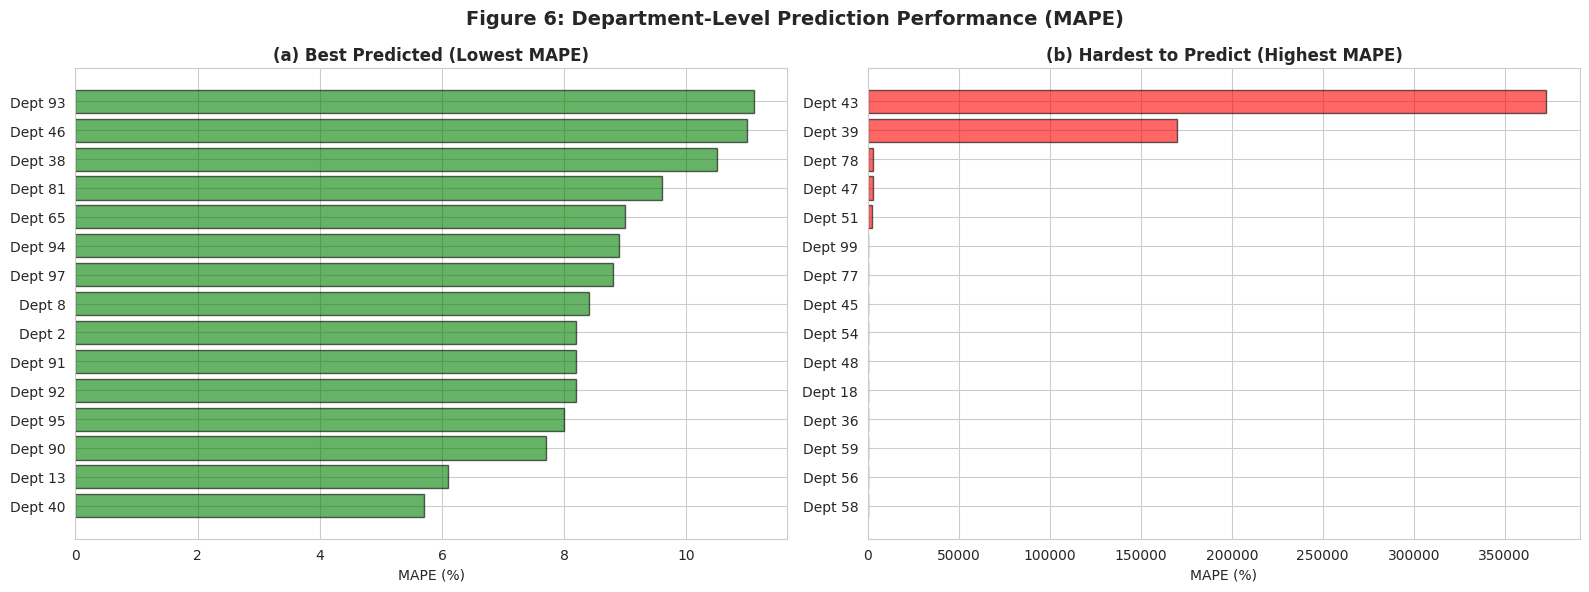

In [30]:
# Figure 6: Department MAPE Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 6: Department-Level Prediction Performance (MAPE)', fontsize=14, fontweight='bold')

# Best predicted departments
best15 = dept_perf.head(15)
axes[0].barh(range(len(best15)), best15['MAPE (%)'], color='green', alpha=0.6, edgecolor='black')
axes[0].set_yticks(range(len(best15)))
axes[0].set_yticklabels([f'Dept {i}' for i in best15.index])
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('(a) Best Predicted (Lowest MAPE)', fontweight='bold')

# Hardest to predict
hard15 = dept_perf.tail(15)
axes[1].barh(range(len(hard15)), hard15['MAPE (%)'], color='red', alpha=0.6, edgecolor='black')
axes[1].set_yticks(range(len(hard15)))
axes[1].set_yticklabels([f'Dept {i}' for i in hard15.index])
axes[1].set_xlabel('MAPE (%)')
axes[1].set_title('(b) Hardest to Predict (Highest MAPE)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{data_dir}/figure_6_department_mape.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {data_dir}/figure_6_department_mape.png")
plt.show()

In [31]:
# Table 16: Overall MAPE Summary
overall = pd.DataFrame({
    'Metric': ['Total Departments', 'Mean MAPE (%)', 'Median MAPE (%)',
               'Best MAPE (%)', 'Worst MAPE (%)', 'Std Dev MAPE (%)'],
    'Value':  [
        len(dept_perf),
        f"{dept_perf['MAPE (%)'].mean():.1f}",
        f"{dept_perf['MAPE (%)'].median():.1f}",
        f"{dept_perf['MAPE (%)'].min():.1f}",
        f"{dept_perf['MAPE (%)'].max():.1f}",
        f"{dept_perf['MAPE (%)'].std():.1f}"
    ]
})
print("Table 16: Overall Department MAPE Summary\n")
print(overall.to_string(index=False))

Table 16: Overall Department MAPE Summary

           Metric    Value
Total Departments       81
    Mean MAPE (%)   6828.5
  Median MAPE (%)     21.8
    Best MAPE (%)      5.7
   Worst MAPE (%) 372780.0
 Std Dev MAPE (%)  45292.0


## 3.7 Final Summary & Model Recommendations

In [32]:
# Table 17: Final Summary
summary_final = pd.DataFrame({
    'Aspect': [
        'Best Model',
        'Best Model RMSE',
        'Best Model MAE',
        'Best Model R²',
        'Training Set Size',
        'Validation Set Size',
        'Number of Features',
        'Top Feature (RF)',
        'Mean Department MAPE'
    ],
    'Value': [
        best_name,
        f'${best_rmse:,.2f}',
        f'${best_rmse if best_name == "XGBoost" else (lr_mae if best_name == "Linear Regression" else rf_mae):,.2f}',
        f'{best_r2:.4f}',
        f'{len(train_data):,}',
        f'{len(val_data):,}',
        len(feature_cols),
        rf_imp.iloc[0]['Feature'],
        f"{dept_perf['MAPE (%)'].mean():.1f}%"
    ]
})
print("\n" + "="*60)
print("TABLE 17: FINAL PROJECT SUMMARY")
print("="*60 + "\n")
print(summary_final.to_string(index=False))
print("\n" + "="*60)


TABLE 17: FINAL PROJECT SUMMARY

              Aspect         Value
          Best Model Random Forest
     Best Model RMSE     $4,238.28
      Best Model MAE     $2,167.09
       Best Model R²        0.9628
   Training Set Size       338,738
 Validation Set Size        82,832
  Number of Features            13
    Top Feature (RF)          Dept
Mean Department MAPE       6828.5%



In [33]:
# Print data directory location for reference
print(f"\n✓ All outputs saved to: {data_dir}")
print(f"\n✓ Generated files:")
print(f"  - walmart_merged.csv (unified dataset)")
print(f"  - figure_1_temperature_analysis.png")
print(f"  - figure_2_department_analysis.png")
print(f"  - figure_3_model_comparison.png")
print(f"  - figure_4_best_model_evaluation.png")
print(f"  - figure_5_feature_importance.png")
print(f"  - figure_6_department_mape.png")


✓ All outputs saved to: /sessions/festive-great-meitner/mnt/utsav

✓ Generated files:
  - walmart_merged.csv (unified dataset)
  - figure_1_temperature_analysis.png
  - figure_2_department_analysis.png
  - figure_3_model_comparison.png
  - figure_4_best_model_evaluation.png
  - figure_5_feature_importance.png
  - figure_6_department_mape.png
